In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import DenseGCNConv
from torch_geometric.utils import to_dense_batch
from torch_geometric.datasets import PPI
from torch_geometric.loader import DataLoader
from sklearn.metrics import f1_score

class DynamicGSL_PPI(nn.Module):
    def __init__(self, num_features, num_classes, hidden_dim=256):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.alpha = nn.Parameter(torch.tensor(2.0))
        
        # UPGRADE 1: O Gerador de Estrutura agora é um MLP Não-Linear
        self.projection = nn.Sequential(
            nn.Linear(num_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        
        # UPGRADE 2: Três camadas GCN em vez de duas
        self.gcn1 = DenseGCNConv(num_features, hidden_dim)
        self.gcn2 = DenseGCNConv(hidden_dim, hidden_dim)
        self.gcn3 = DenseGCNConv(hidden_dim, num_classes)
        
        # UPGRADE 3: Normalização para matar a "tremedeira" do gráfico
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)

    def normalize_adj(self, adj):
        eye = torch.eye(adj.size(-1), device=adj.device).unsqueeze(0)
        adj_hat = adj + eye
        deg = adj_hat.sum(dim=-1)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt.masked_fill_(deg_inv_sqrt == float('inf'), 0)
        return deg_inv_sqrt.unsqueeze(-1) * adj_hat * deg_inv_sqrt.unsqueeze(1)

    def forward(self, x_dense, adj_orig, mask):
        # 1. Gerar Matriz Dinâmica (Agora com cérebro MLP)
        z = self.projection(x_dense) 
        adj_raw = torch.matmul(z, z.transpose(1, 2)) / (self.hidden_dim ** 0.5)
        adj_probs = torch.sigmoid(adj_raw)
        
        mask_float = mask.float()
        adj_learned = adj_probs * mask_float.unsqueeze(-1) * mask_float.unsqueeze(1)
        
        # 2. Balança da Fusão (Alpha)
        alpha_val = torch.sigmoid(self.alpha)
        adj_combined = (alpha_val * adj_orig) + ((1.0 - alpha_val) * adj_learned)
        adj_norm = self.normalize_adj(adj_combined)
        
        # 3. Passagem pelas 3 Camadas GCN com Normalização
        x = self.gcn1(x_dense, adj_norm, add_loop=False)
        x = self.norm1(x) # Estabiliza os valores
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.gcn2(x, adj_norm, add_loop=False)
        x = self.norm2(x) # Estabiliza os valores novamente
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.gcn3(x, adj_norm, add_loop=False)
        
        return x, adj_learned

In [30]:
from torch_geometric.utils import to_dense_adj

path = './data/PPI'
train_dataset = PPI(root=path, split='train')
val_dataset = PPI(root=path, split='val')
test_dataset = PPI(root=path, split='test')

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DynamicGSL_PPI(train_dataset.num_features, train_dataset.num_classes).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_dynamic(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        x_dense, mask = to_dense_batch(data.x, data.batch)
        
        adj_orig = to_dense_adj(data.edge_index, data.batch)
        
        out, _ = model(x_dense, adj_orig, mask)
        
        out_real = out[mask]
        
        loss = criterion(out_real, data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_dynamic(model, loader, criterion):
    model.eval()
    total_loss = 0
    y_true, y_pred = [], []
    for data in loader:
        data = data.to(device)
        x_dense, mask = to_dense_batch(data.x, data.batch)
        
        # NOVO: Puxa a matriz original com o batch size correto
        adj_orig = to_dense_adj(data.edge_index, data.batch)
        
        # Passa os 3 para o modelo
        out, _ = model(x_dense, adj_orig, mask)
        out_real = out[mask]
        
        loss = criterion(out_real, data.y)
        total_loss += loss.item() * data.num_graphs
        
        probs = torch.sigmoid(out_real)
        preds = (probs > 0.5).float()
        
        y_true.append(data.y.cpu())
        y_pred.append(preds.cpu())
        
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    f1 = f1_score(y_true, y_pred, average='micro')
    return total_loss / len(loader.dataset), f1


train_losses = []
val_losses = []
val_f1_list = []

best_val_acc = 0.0
best_weights = None
best_epoch = 0

# --- LOOP PRINCIPAL ---
print("A iniciar o treino do Modelo Dinâmico (GSL)...")
for epoch in range(1, 101):
    train_loss = train_dynamic(model, train_loader, optimizer, criterion)
    val_loss, val_f1 = evaluate_dynamic(model, val_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss) 
    val_f1_list.append(val_f1)
    
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}')
    
test_loss, test_f1 = evaluate_dynamic(model, test_loader, criterion)
print(f'\n--- TESTE FINAL ---')
print(f'F1-Score no Teste (GSL Dinâmico): {test_f1:.4f}')

A iniciar o treino do Modelo Dinâmico (GSL)...
Epoch 001 | Train Loss: 0.6192 | Val Loss: 0.5507 | Val F1: 0.4084
Epoch 010 | Train Loss: 0.5474 | Val Loss: 0.5371 | Val F1: 0.4146
Epoch 020 | Train Loss: 0.5393 | Val Loss: 0.5320 | Val F1: 0.4348
Epoch 030 | Train Loss: 0.5355 | Val Loss: 0.5298 | Val F1: 0.4056
Epoch 040 | Train Loss: 0.5337 | Val Loss: 0.5285 | Val F1: 0.4564
Epoch 050 | Train Loss: 0.5367 | Val Loss: 0.5282 | Val F1: 0.4533
Epoch 060 | Train Loss: 0.5270 | Val Loss: 0.5208 | Val F1: 0.4468
Epoch 070 | Train Loss: 0.5230 | Val Loss: 0.5181 | Val F1: 0.4657
Epoch 080 | Train Loss: 0.5183 | Val Loss: 0.5395 | Val F1: 0.4923
Epoch 090 | Train Loss: 0.5156 | Val Loss: 0.5242 | Val F1: 0.5027
Epoch 100 | Train Loss: 0.5168 | Val Loss: 0.5204 | Val F1: 0.4977

--- TESTE FINAL ---
F1-Score no Teste (GSL Dinâmico): 0.5203


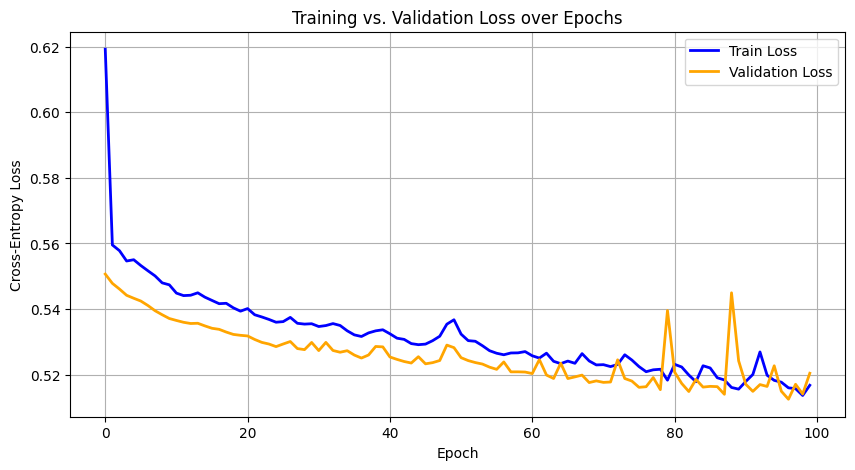

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training vs. Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()